## 1. Normalization (Min-Max Scaling)
* Definition: Rescaling features to a fixed range, typically $[0, 1]$, using the formula $x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$.
* Use Cases:
    * Image processing (scaling pixel values from $[0, 255]$ to $[0, 1]$), neural networks, and distance-based algorithms like KNN.
* Pros:
    * Preserves the exact shape of the original distribution structure.
    * Keeps all features strictly bounded within a defined range.
* Cons:
    * Extremely sensitive to outliers; a single extreme value can compress the rest of the data into a very narrow range.

## 2. Standardization (Z-score Scaling)
* Definition: Scaling features to have a mean ($\mu$) of 0 and a standard deviation ($\sigma$) of 1 using the formula $x_{scaled} = \frac{x - \mu}{\sigma}$.
* Use Cases:
    * Algorithms that assume a Gaussian (normal) distribution, such as Linear/Logistic Regression, Support Vector Machines (SVMs), and PCA.
* Pros:
    * Less sensitive to extreme outliers compared to Min-Max normalization.
    * Centers the data around zero, optimizing gradient descent convergence.
* Cons:
    * Does not bound values to a strict upper and lower limit.

## 3. Feature Scaling
* Definition: The overarching preprocessing step of standardizing or normalizing the independent variables of a dataset to ensure they contribute equally to model updates.
* Use Cases:
    * Any multi-feature dataset where variables have vastly different units or magnitudes (e.g., combining age in years with income in dollars).
* Pros:
    * Prevents features with large numerical scales from dominating the loss function and optimization path.
    * Accelerates the convergence speed of gradient descent.
* Cons:
    * Must be applied carefully (fitting scalers only on training data) to avoid data leakage into validation/test sets.

### Visualization: Normalization vs. Standardization
The code below generates a synthetic dataset containing an outlier and visualizes how Normalization and Standardization transform the feature distributions differently.

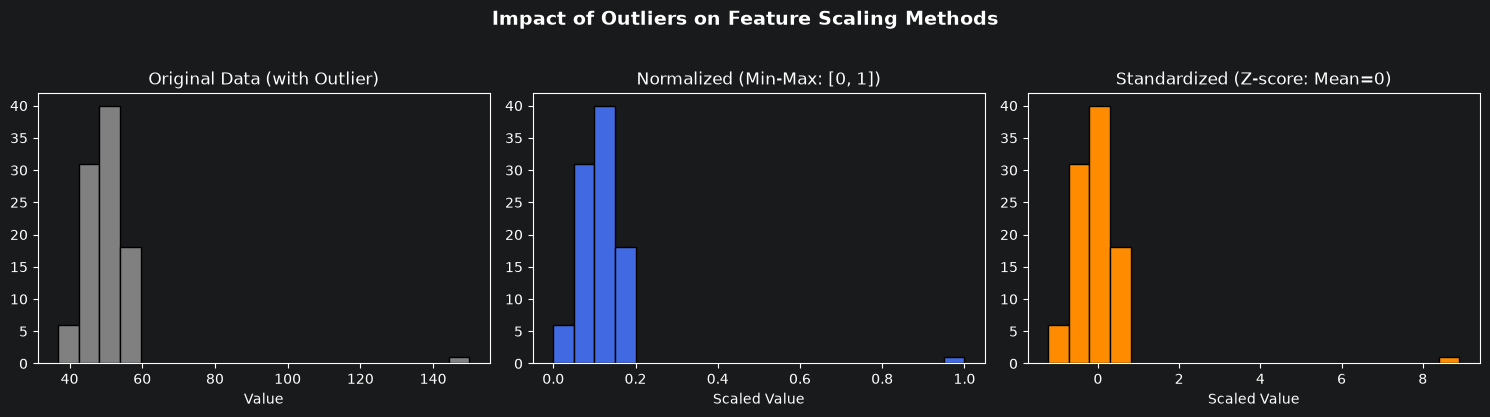

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1. Generate synthetic data with an outlier
np.random.seed(42)
data = np.concatenate([np.random.normal(loc=50, scale=5, size=95), [150]]) # 150 is an outlier
data = data.reshape(-1, 1)

# 2. Apply Normalization and Standardization
scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()

data_normalized = scaler_minmax.fit_transform(data)
data_standardized = scaler_standard.fit_transform(data)

# 3. Plotting comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(data, bins=20, color='gray', edgecolor='black')
axes[0].set_title("Original Data (with Outlier)")
axes[0].set_xlabel("Value")

axes[1].hist(data_normalized, bins=20, color='royalblue', edgecolor='black')
axes[1].set_title("Normalized (Min-Max: [0, 1])")
axes[1].set_xlabel("Scaled Value")

axes[2].hist(data_standardized, bins=20, color='darkorange', edgecolor='black')
axes[2].set_title("Standardized (Z-score: Mean=0)")
axes[2].set_xlabel("Scaled Value")

plt.suptitle("Impact of Outliers on Feature Scaling Methods", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 4. One-Hot Encoding
* Definition: Converting categorical variables into a binary matrix/vector representation where each category is represented by a binary column containing a single '1' and zeros elsewhere.
* Use Cases:
    * Nominal categorical features (e.g., colors, cities, product types) used in linear models or neural networks.
* Pros:
    * Prevents models from assuming an artificial ordinal (numerical) relationship between independent categorical classes.
* Cons:
    * Can cause feature explosion (the curse of dimensionality) if a categorical column has hundreds or thousands of unique values.

## 5. Label Encoding
* Definition: Assigning each unique category a unique sequential integer value (e.g., Low=0, Medium=1, High=2).
* Use Cases:
    * Ordinal categorical variables or target labels ($y$) for tree-based models (like Random Forests or XGBoost).
* Pros:
    * Maintains a compact memory footprint by keeping categorical columns as single integer vectors.
* Cons:
    * Implicitly introduces a mathematical hierarchy ($2 > 1 > 0$) which can mislead distance-based or linear algorithms into misinterpreting categories as numerical quantities.

## Visualization: Comparing One-Hot Encoding vs. Label Encoding
* The structural difference between the two techniques lies in how they represent data. Label Encoding maps categories to a single column of sequential integers, whereas One-Hot Encoding expands categories into multiple binary (0 or 1) columns.
* The comparison script below applies both methods to the same categorical column and combines them into a single side-by-side DataFrame to clearly illustrate how each transformation changes the data structure.

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, HTML

# 1. Sample dataset
df = pd.DataFrame({"City": ["New York", "London", "Paris", "London", "New York"]})

# 2. Prepare Label Encoding DataFrame
df_label = df.copy()
le = LabelEncoder()
df_label["Label_Encoded"] = le.fit_transform(df["City"])

# 3. Prepare One-Hot Encoding DataFrame
df_onehot = pd.get_dummies(df["City"], prefix="City").astype(int)

# 4. Create side-by-side HTML layout
html_code = f"""
<div style="display: flex; justify-content: space-around; align-items: flex-start; gap: 30px; font-family: Arial, sans-serif;">
    <div style="flex: 1; text-align: center;">
        <h4 style="color: #333;">Label Encoding</h4>
        {df_label.to_html(index=True, classes="table table-striped", border=0)}
    </div>
    <div style="flex: 1; text-align: center;">
        <h4 style="color: #333;">One-Hot Encoding</h4>
        {df_onehot.to_html(index=True, classes="table table-striped", border=0)}
    </div>
</div>
"""

# Render the side-by-side tables
display(HTML(html_code))

## 6. Missing Data Handling
* Definition: The process of identifying and resolving absent, null, or corrupted data entries through deletion or imputation (e.g., filling missing values with mean, median, mode, or KNN prediction).
* Use Cases:
    * Cleaning raw, real-world tabular datasets before training machine learning models.
* Pros:
    * Prevents execution crashes and runtime errors in mathematical matrix algorithms.
    * Imputation preserves valuable rows that would otherwise be discarded.
* Cons:
    * Imputing values can introduce artificial statistical bias or distort the underlying distribution variance.

## 7. Class Imbalance Handling
* Definition: Techniques used to address datasets where one target class vastly outnumbers others (e.g., 99% non-fraud vs. 1% fraud), using resampling (oversampling/undersampling, SMOTE) or algorithmic adjustments (class weights).
* Use Cases:
    * Fraud detection, rare medical disease diagnosis, and anomaly detection.
* Pros:
    * Prevents models from collapsing into lazy predictors that achieve high accuracy simply by guessing the majority class.
* Cons:
    * Oversampling (like duplicating minority data or generating synthetic points via SMOTE) can lead to overfitting; undersampling can discard crucial information.